# Sales Prediction and Marketing Spend Optimization

## Table of Contents
1. [Import Libraries & Load Data](#1.-Import-Libraries-&-Load-Data)
2. [Exploratory Data Analysis (EDA)](#2.-Exploratory-Data-Analysis-(EDA))
3. [Data Preprocessing & Feature Engineering](#3.-Data-Preprocessing-&-Feature-Engineering)
4. [Train-Test Split](#4.-Train-Test-Split)
5. [Building & Training the ML Pipeline](#5.-Building-&-Training-the-ML-Pipeline)
6. [Model Evaluation & Visualization](#6.-Model-Evaluation-&-Visualization)
7. [Business Insights & Marketing Strategies](#7.-Business-Insights-&-Marketing-Strategies)

## 1. Import Libraries & Load Data

In [1]:
# Importing data processing and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing ML libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# Configure notebook plotting styles
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/omaraftab/advertising-dataset/Advertising.csv')
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


## 2. Exploratory Data Analysis (EDA)

In [4]:
# Checking for null values and verifying data types
print("--- Missing Values Check ---")
print(df.isnull().sum())

--- Missing Values Check ---
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [5]:
print("\n--- Summary Statistics ---")
display(df.describe())


--- Summary Statistics ---


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


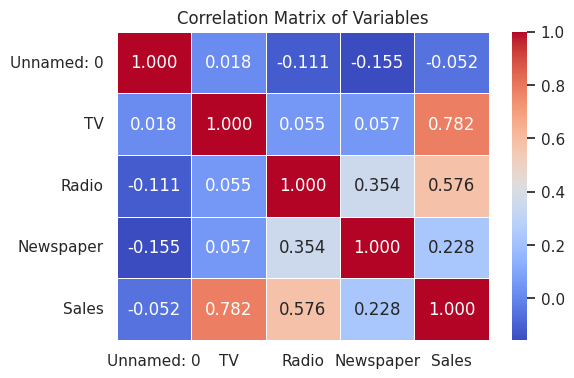

In [6]:
# Compute and plot correlation matrix heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title("Correlation Matrix of Variables")
plt.show()

## 3. Data Preprocessing & Feature Engineering

In [7]:
# Separating Independent Variables (Features) and Dependent Variable (Target)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print("Features selected: TV, Radio, Newspaper")
print("Target variable selected: Sales")

Features selected: TV, Radio, Newspaper
Target variable selected: Sales


## 4. Train-Test Split

In [8]:
# Segment data into 80% Training and 20% Testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Features Matrix Shape: {X_train.shape}")
print(f"Testing Features Matrix Shape:  {X_test.shape}")

Training Features Matrix Shape: (160, 3)
Testing Features Matrix Shape:  (40, 3)


## 5. Building & Training the ML Pipeline

In [9]:
# fiting the Multiple Linear Regression model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [10]:
# Predicting sales outcomes on the validation test partition
y_pred = regressor.predict(X_test)

print("Linear Regression pipeline successfully built and trained!")

Linear Regression pipeline successfully built and trained!


## 6. Model Evaluation & Visualization

In [11]:
# Compute core evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Mean Absolute Error (MAE):     {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coefficient of Determination ($R^2$): {r2:.4f}  (Explains ~{r2*100:.1f}% of data variance)")

--- Model Performance Metrics ---
Mean Absolute Error (MAE):     1.4608
Root Mean Squared Error (RMSE): 1.7816
Coefficient of Determination ($R^2$): 0.8994  (Explains ~89.9% of data variance)


In [12]:
# Extract parameters to evaluate channel impacts
coefficients = pd.DataFrame(regressor.coef_, X.columns, columns=['Coefficient'])
print("\n--- Regression Intercept & Coefficients ---")
print(f"Baseline Sales Intercept: {regressor.intercept_:.4f}")
display(coefficients)


--- Regression Intercept & Coefficients ---
Baseline Sales Intercept: 2.9791


,Coefficient
TV,0.044730
Radio,0.189195
Newspaper,0.002761


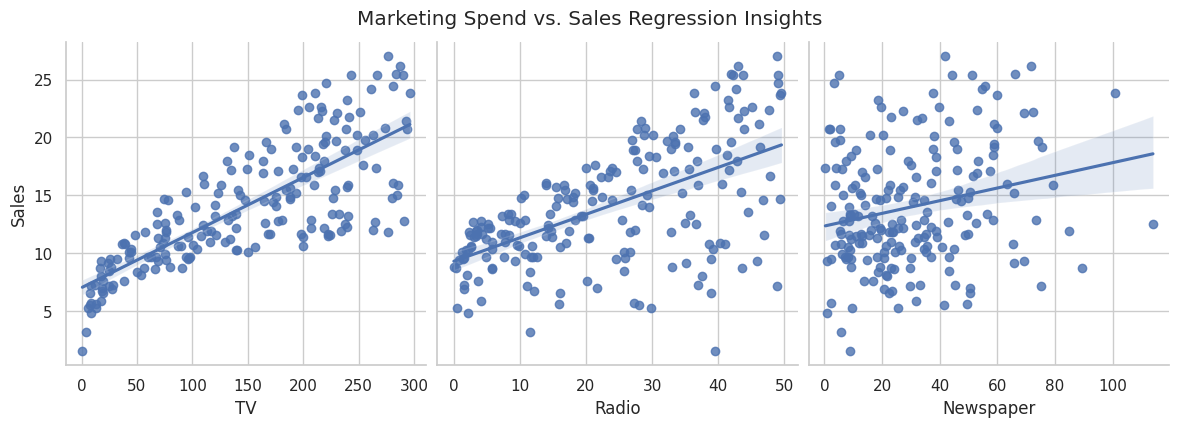

In [13]:
# Visualizing features vs Sales using pair regression plots
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='reg')
plt.suptitle("Marketing Spend vs. Sales Regression Insights", y=1.05)
plt.show()

> * **TV:** Displays a tight, highly linear upward trend, indicating reliable and consistent sales growth as budget scales.
> * **Radio:** Shows a clear positive upward trend, reflecting high conversion efficiency per unit of advertising spend.
> * **Newspaper:** Presents a highly scattered data plot with a flat regression line, highlighting a weak relationship and minimal impact on sales.

## 7. Business Insights & Marketing Strategies

Based on our final trained model, we evaluated the relationship between channel-specific advertising spend and sales outcomes. The data yields highly accurate and actionable business intelligence.

#### **Model Reliability & Performance Accuracy**
* **Goodness of Fit ($R^2 = 0.8994$):** Approximately **$89.94\%$ of all variance in Sales** is directly driven by changes in TV, Radio, and Newspaper advertising budgets. This strong performance leaves only roughly $10\%$ of sales variations to external factors (like seasonal shifts or competitor pricing).
* **Prediction Precision:** The model displays a **Mean Absolute Error (MAE) of 1.4608** and a **Root Mean Squared Error (RMSE) of 1.7816**. This proves that our pipeline can predict future sales outcomes with an expected margin of error of less than 1.8 units, allowing for reliable inventory planning and revenue forecasting.

#### **Core Platform Breakdown & Impact Analysis**
* **Baseline Sales Intercept ($\approx 2.9791$):** If marketing budgets for TV, Radio, and Newspaper were completely cut to zero, the company would still expect a baseline of roughly **2.98 units of organic sales**, driven purely by existing brand equity, word of mouth, or organic traffic.
* **Radio (Highest Growth Potential):** For every single unit increase in Radio advertising spend, sales scale upwards by **0.1892 units**. This represents the most efficient dollar-for-dollar channel for immediate growth.
* **TV (Stable Baseline Reach):** For every single unit increase in TV advertising spend, sales grow by **0.0447 units**. While the per-unit growth is lower than Radio, its massive target reach capabilities anchor the broad baseline of the conversion funnel.
* **Newspaper (Negligible Return on Investment):** The Newspaper coefficient is **0.0028**, which is effectively close to zero. Shifts in traditional print spending demonstrate no statistically valid relationship with driving final sales numbers.

#### **Actionable Strategic Recommendations**
1. **Defund Traditional Print Media:** Stop or substantially minimize the budgets currently allocated to **Newspaper** campaigns. The data clearly shows that shifting capital into this medium does not trigger measurable sales momentum.
2. **Aggressively Scale Audio & Streaming Platforms:** Reallocate your saved print media budgets directly into **Radio, Digital Audio, and Podcast Networks**. Because it has the highest per-unit impact coefficient, scaling this channel optimizes your customer acquisition costs (CAC).
3. **Protect TV Budget as a Core Baseline:** Maintain stable, calculated spend metrics in **TV commercials**. TV provides the broad reach necessary to fill the top of your marketing funnel, which Radio can then efficiently convert at a higher rate.